<a href="https://colab.research.google.com/github/arxsyy/MachineLearning_2026/blob/main/JS05_TUGAS2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import library untuk pengolahan dan visualisasi data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset spam
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

# Mengambil kolom label dan teks SMS
df = df[['v1', 'v2']]

# Mengganti nama kolom sesuai modul
df.columns = ['Labels', 'SMS']

# Menampilkan lima baris pertama
df.head()

,Labels,SMS
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
# Menampilkan dimensi dataset
print("Dimensi data:", df.shape)

# Menampilkan jumlah data setiap kelas
print("\nJumlah data per kelas:")
print(df['Labels'].value_counts())

# Memeriksa kelengkapan dataset
print("\nMissing value:")
print(df.isnull().sum())

# Menampilkan informasi dataset
print("\nInformasi dataset:")
df.info()

Dimensi data: (5572, 2)

Jumlah data per kelas:
Labels
ham     4825
spam     747
Name: count, dtype: int64

Missing value:
Labels    0
SMS       0
dtype: int64

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Labels  5572 non-null   object
 1   SMS     5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [3]:
# Import fungsi pembagian dataset
from sklearn.model_selection import train_test_split

# Menentukan fitur teks dan target
X = df['SMS']
y = df['Labels']

# Membagi data menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Menampilkan ukuran data
print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (4457,)
Data testing : (1115,)


**Tugas 1 – Multinomial Naive Bayes dengan CountVectorizer**

In [4]:
# Import library CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Membuat objek CountVectorizer dengan stop words
bow = CountVectorizer(stop_words='english')

# Mengubah teks training menjadi fitur numerik
X_train_bow = bow.fit_transform(X_train)

# Mengubah teks testing menggunakan vocabulary training
X_test_bow = bow.transform(X_test)

# Menampilkan jumlah fitur dan dimensi data
print("Jumlah fitur:", len(bow.get_feature_names_out()))
print("Dimensi training:", X_train_bow.shape)
print("Dimensi testing :", X_test_bow.shape)

Jumlah fitur: 7440
Dimensi training: (4457, 7440)
Dimensi testing : (1115, 7440)


In [5]:
# Import model Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Membuat model Multinomial Naive Bayes
model_bow = MultinomialNB()

# Melatih model dengan data training
model_bow.fit(X_train_bow, y_train)

# Melakukan prediksi terhadap data testing
y_pred_bow = model_bow.predict(X_test_bow)

In [6]:
# Import metrik evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Menghitung metrik evaluasi
acc_bow = accuracy_score(y_test, y_pred_bow)
precision_bow = precision_score(
    y_test, y_pred_bow, pos_label='spam'
)
recall_bow = recall_score(
    y_test, y_pred_bow, pos_label='spam'
)
f1_bow = f1_score(
    y_test, y_pred_bow, pos_label='spam'
)

# Menampilkan hasil evaluasi
print("Evaluasi CountVectorizer")
print("Akurasi   :", acc_bow)
print("Precision :", precision_bow)
print("Recall    :", recall_bow)
print("F1-Score  :", f1_bow)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_bow))

Evaluasi CountVectorizer
Akurasi   : 0.9838565022421525
Precision : 0.958041958041958
Recall    : 0.9194630872483222
F1-Score  : 0.9383561643835616

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



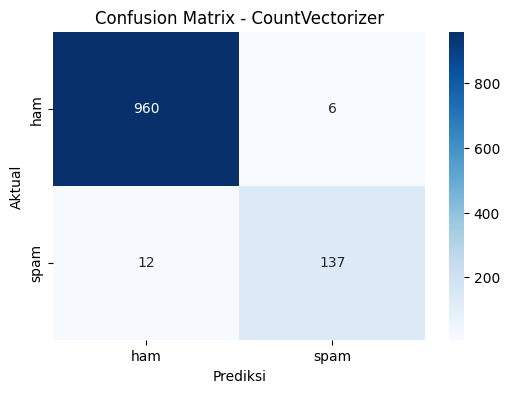

In [7]:
# Membuat confusion matrix
cm_bow = confusion_matrix(
    y_test,
    y_pred_bow,
    labels=['ham', 'spam']
)

# Menampilkan confusion matrix dengan heatmap
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_bow,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam']
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - CountVectorizer')
plt.show()

Analisis tugas 1: Model menggunakan representasi frekuensi kata dan menghilangkan stop words sebelum proses klasifikasi. Hasil evaluasi digunakan untuk melihat ketepatan model dalam membedakan pesan normal dan spam. Confusion matrix memperlihatkan jumlah klasifikasi benar serta kesalahan dalam kedua kelas.

**Tugas 2 – Multinomial Naive Bayes dengan TF-IDF**

In [8]:
# Import library TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat objek TF-IDF dengan stop words
tfidf = TfidfVectorizer(stop_words='english')

# Mengubah teks training menjadi fitur TF-IDF
X_train_tfidf = tfidf.fit_transform(X_train)

# Mengubah teks testing menggunakan TF-IDF training
X_test_tfidf = tfidf.transform(X_test)

# Menampilkan jumlah fitur dan dimensi data
print("Jumlah fitur:", len(tfidf.get_feature_names_out()))
print("Dimensi training:", X_train_tfidf.shape)
print("Dimensi testing :", X_test_tfidf.shape)

Jumlah fitur: 7440
Dimensi training: (4457, 7440)
Dimensi testing : (1115, 7440)


In [9]:
# Membuat model Multinomial Naive Bayes
model_tfidf = MultinomialNB()

# Melatih model menggunakan fitur TF-IDF
model_tfidf.fit(X_train_tfidf, y_train)

# Melakukan prediksi terhadap data testing
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

In [10]:
# Menghitung metrik evaluasi TF-IDF
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
precision_tfidf = precision_score(
    y_test, y_pred_tfidf, pos_label='spam'
)
recall_tfidf = recall_score(
    y_test, y_pred_tfidf, pos_label='spam'
)
f1_tfidf = f1_score(
    y_test, y_pred_tfidf, pos_label='spam'
)

# Menampilkan hasil evaluasi
print("Evaluasi TF-IDF")
print("Akurasi   :", acc_tfidf)
print("Precision :", precision_tfidf)
print("Recall    :", recall_tfidf)
print("F1-Score  :", f1_tfidf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf))

Evaluasi TF-IDF
Akurasi   : 0.968609865470852
Precision : 1.0
Recall    : 0.7651006711409396
F1-Score  : 0.8669201520912547

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



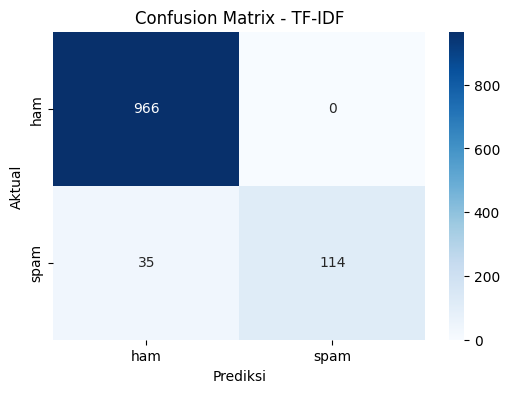

In [11]:
# Membuat confusion matrix TF-IDF
cm_tfidf = confusion_matrix(
    y_test,
    y_pred_tfidf,
    labels=['ham', 'spam']
)

# Menampilkan confusion matrix dengan heatmap
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_tfidf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam']
)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - TF-IDF')
plt.show()

**Tugas 3 – Perbandingan Hasil dan Kesimpulan**

In [12]:
# Membuat tabel perbandingan hasil evaluasi
perbandingan = pd.DataFrame({
    'Metode': [
        'CountVectorizer',
        'TF-IDF'
    ],
    'Akurasi': [
        acc_bow,
        acc_tfidf
    ],
    'Precision': [
        precision_bow,
        precision_tfidf
    ],
    'Recall': [
        recall_bow,
        recall_tfidf
    ],
    'F1-Score': [
        f1_bow,
        f1_tfidf
    ]
})

# Menampilkan hasil perbandingan
perbandingan

,Metode,Akurasi,Precision,Recall,F1-Score
0,CountVectorizer,0.983857,0.958042,0.919463,0.938356
1,TF-IDF,0.968610,1.000000,0.765101,0.866920


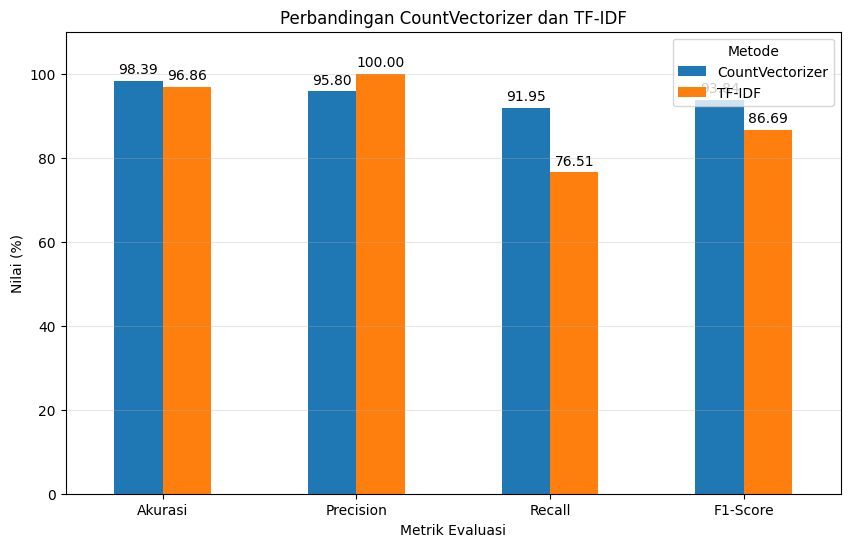

In [13]:
# Mengubah nilai metrik menjadi persentase
data_grafik = perbandingan.set_index('Metode') * 100

# Membuat grafik perbandingan kedua metode
ax = data_grafik.T.plot(
    kind='bar',
    figsize=(10, 6),
    rot=0
)

plt.title('Perbandingan CountVectorizer dan TF-IDF')
plt.xlabel('Metrik Evaluasi')
plt.ylabel('Nilai (%)')
plt.ylim(0, 110)
plt.legend(title='Metode')
plt.grid(axis='y', alpha=0.3)

# Menampilkan nilai pada setiap batang
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.show()

Berdasarkan hasil evaluasi, CountVectorizer menghasilkan akurasi sebesar 98,39%, sedangkan TF-IDF menghasilkan akurasi sebesar 96,86%. Hal ini menunjukkan bahwa CountVectorizer memiliki tingkat ketepatan klasifikasi keseluruhan yang lebih tinggi pada percobaan ini.

TF-IDF menghasilkan precision spam sebesar 100%, yang berarti tidak ada pesan normal yang keliru diprediksi sebagai spam. Namun, recall spam TF-IDF hanya mencapai 76,51%, sehingga lebih banyak pesan spam yang tidak berhasil dideteksi.

Sementara itu, CountVectorizer menghasilkan recall spam sebesar 91,95% dan F1-score sebesar 93,84%. Kedua nilai tersebut lebih tinggi dibandingkan hasil TF-IDF, sehingga CountVectorizer memiliki keseimbangan precision dan recall yang lebih baik dalam percobaan ini.

Berdasarkan percobaan klasifikasi SMS menggunakan Multinomial Naive Bayes, metode CountVectorizer memberikan hasil lebih baik secara keseluruhan dibandingkan TF-IDF pada dataset yang digunakan.

CountVectorizer menghasilkan akurasi sebesar 98,39% dan F1-score spam sebesar 93,84%, sedangkan TF-IDF menghasilkan akurasi sebesar 96,86% dan F1-score spam sebesar 86,69%.

Dengan demikian, CountVectorizer merupakan pilihan yang lebih sesuai untuk percobaan ini jika tujuan utamanya adalah mendeteksi sebanyak mungkin pesan spam dengan tetap mempertahankan tingkat ketepatan yang tinggi. Namun, apabila prioritasnya adalah menghindari pesan normal yang salah diklasifikasikan sebagai spam, TF-IDF menunjukkan precision yang lebih tinggi.

Kesimpulan tersebut berlaku untuk dataset, pembagian data, dan parameter model yang digunakan dalam percobaan ini.